In [1]:
import numpy as np
import pandas as pd
import nbformat
import plotly.express as px
from plotly import tools
import plotly.offline as py
import plotly.graph_objs as go


In [2]:
# Download files
# run analyze_awstats
# Use this to parse files

In [3]:
ros2 = ["ardent","bouncy","crystal","dashing","eloquent","foxy","galactic","humble","iron","jazzy","kilted","rolling"]
ros1 = ["boxturtle","cturtle","diamondback","electric","fuerte","groovy","hydro","indigo","jade","kinetic","lunar","melodic","noetic"]
# This are just values for the input files
this_year = "2026"
this_month = "January"
last_year = "2025"
last_month = "January"

In [4]:
def process_package_dump(fname,date):
    package_counts = [] 
    distro_counts = []
    arch_counts = []
    arch_x_os_counts = []
    stats = []
    with open(fname,'r') as fp:
        # remove the first line
        f = fp.readline()

        # remove all the empty 
        f = fp.readline()
        print("Removing non-ROS packages")

        while "not a ros package name" in f:
            f = fp.readline()

        print("Doing package counts...")
        
        while "Breakdown" not in f:
            try:
                temp = f.split(":")
                parts = temp[0].split("-")
                distro = parts[1]
                package = "-".join(parts[2:])
                data = {       
                    "package":package,
                    "distro":distro,
                    "name":temp[0],
                    "count":int(temp[1]),
                    "date":date}
                package_counts.append(data)
            except:
                print("Error on line {0}".format(f))
            f = fp.readline()
            
        # Done with the modules 
        print("Doing distros.")
        
        f = fp.readline()
        while "Breakdown" not in f:
            try:
                temp = f.split(":")                            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date
                }
                distro_counts.append(data)
            except:
                print("Error on line {0}".format(f))
            
            f = fp.readline()

        f = fp.readline()
        print("Doing arches.")
        
        while "Results" not in f:
            try:
                temp = f.split(":")            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date}
                arch_counts.append(data)
            except:
                print("Error on line {0}".format(f))            
            
            f = fp.readline()

        f = fp.readline()
    
        print("Doing arch X OS.")

        while "Unique" not in f:
            try:
                temp = f.split(":")            
                data = {
                    "name":temp[0],
                    "prct":float(temp[1].replace("%","")),
                    "date":date}
                arch_x_os_counts.append(data)
            except:
                print("Error on line {0}".format(f))                
            
            f = fp.readline()

        print("Doing stats.")

        f = fp.readline()    
        while len(f) > 0:
            try:
                temp = f.split(":")
                data = {
                    "name":temp[0],
                    "prct":temp[1],
                    "date":date }
                stats.append((temp[0],temp[1]))
            except:
                print("Error on line {0}".format(f))
        
            f = fp.readline()

    retval = {}
    retval["package"] = package_counts
    retval["distro"] = distro_counts
    retval["arch"] = arch_counts
    retval["arch_x_os"] = arch_x_os_counts
    retval["stats"] = stats
    return retval


In [5]:
# Load and process the dumps from analyze_awstats.py as dictionaries
fname = "./Jan2025.txt"
stats_last = process_package_dump(fname,last_year)
fname = "./Jan2026.txt"
stats_this = process_package_dump(fname,this_year)

Removing non-ROS packages
Doing package counts...
Doing distros.
Doing arches.
Error on line ==============================

Error on line Breakdown by Arch:

Doing arch X OS.
Doing stats.
Removing non-ROS packages
Doing package counts...
Doing distros.
Doing arches.
Error on line ==============================

Error on line Breakdown by Arch:

Doing arch X OS.
Doing stats.


In [6]:
# print raw package counts and deb download data
print("#"*30)
print("Diff Packages")
d_this = int(stats_this["stats"][0][1])
d_last = int(stats_last["stats"][0][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))
print("#"*30)
print("Total Deb Downloads")
d_this = int(stats_this["stats"][1][1])
d_last = int(stats_last["stats"][1][1])
print("{0}: {1}".format(last_year,d_last))
print("{0}: {1}".format(this_year,d_this))
print("Percent Change: {0}%".format(100.0*((d_this-d_last)/d_last)))

##############################
Diff Packages
2025: 29261
2026: 34585
Percent Change: 18.194866887666176%
##############################
Total Deb Downloads
2025: 46266523
2026: 149643046
Percent Change: 223.43698271858466%


In [53]:
# print package data
print(len(stats_last["package"]))
print(len(stats_this["package"]))
print(stats_last.keys())
print(stats_last["arch_x_os"])

28481
33807
dict_keys(['package', 'distro', 'arch', 'arch_x_os', 'stats'])
[{'name': 'bionic_amd64', 'prct': 1.38, 'date': '2025'}, {'name': 'bionic_arm64', 'prct': 0.46, 'date': '2025'}, {'name': 'bionic_armhf', 'prct': 0.02, 'date': '2025'}, {'name': 'buster_amd64', 'prct': 0.01, 'date': '2025'}, {'name': 'buster_arm64', 'prct': 0.01, 'date': '2025'}, {'name': 'buster_armhf', 'prct': 0.0, 'date': '2025'}, {'name': 'buster_i386', 'prct': 0.0, 'date': '2025'}, {'name': 'disco_amd64', 'prct': 0.0, 'date': '2025'}, {'name': 'focal_amd64', 'prct': 17.14, 'date': '2025'}, {'name': 'focal_arm64', 'prct': 2.83, 'date': '2025'}, {'name': 'focal_armhf', 'prct': 0.05, 'date': '2025'}, {'name': 'jammy_amd64', 'prct': 42.43, 'date': '2025'}, {'name': 'jammy_arm64', 'prct': 6.69, 'date': '2025'}, {'name': 'noble_amd64', 'prct': 17.87, 'date': '2025'}, {'name': 'noble_arm64', 'prct': 2.16, 'date': '2025'}, {'name': 'stretch_amd64', 'prct': 0.01, 'date': '2025'}, {'name': 'stretch_arm64', 'prct': 0.

In [54]:
def dumb_find(lst, k, v):
    for i, dic in enumerate(lst):
        if dic[k] == v:
            return lst[i]
    return None

def join_stats(stats_list,idx="prct"):
    # join two lists of data into a single dictionary
    joined = []
    # LIST SHOULD BE THE NEWEST FIRST!!!
    first = stats_list[0]
    for entry in first:
        new_entry = {}
        new_entry["name"] = entry["name"]
        new_entry.update(entry)
        del new_entry[idx]
        del new_entry["date"]
        
        new_entry[entry["date"]] = entry[idx]
        for other in stats_list[1:]:
            temp = dumb_find(other,"name",entry["name"])
            if temp:
                new_entry[temp["date"]] = temp[idx]
        joined.append(new_entry)
    return joined

In [9]:
# Join together our distro data and make it into a CSV file 
joined_distro = join_stats([stats_this["distro"],stats_last["distro"]])
distro_df = pd.DataFrame(data=joined_distro)
distro_df.to_csv("distro.csv")
distro_df

,name,2026,2025
0,boxturtle,0.00,0.00
1,cturtle,0.00,0.00
2,diamondback,0.00,0.00
3,electric,0.00,0.00
4,fuerte,0.00,0.00
5,groovy,0.00,0.00
6,hydro,0.00,0.00
7,indigo,0.03,0.14
8,jade,0.00,0.00
9,kinetic,0.14,0.38


In [10]:
# Repeat that process for arch
joined_arch = join_stats([stats_this["arch"],stats_last["arch"]])
arch_df = pd.DataFrame(data=joined_arch)
arch_df.to_csv("arch.csv")
arch_df.head()

,name,2026,2025
0,boxturtle,0.0,0.0
1,cturtle,0.0,0.0
2,diamondback,0.0,0.0
3,electric,0.0,0.0
4,fuerte,0.0,0.0


In [11]:
# Join arch x os data
joined_arch_x_os = join_stats([stats_this["arch_x_os"],stats_last["arch_x_os"]])
arch_os_df = pd.DataFrame(data=joined_arch_x_os)
arch_os_df.to_csv("arch_os.csv")
arch_os_df

,name,2026,2025
0,bionic_amd64,0.57,1.38
1,bionic_arm64,0.17,0.46
2,bionic_armhf,0.01,0.02
3,buster_amd64,0.01,0.01
4,buster_arm64,0.01,0.01
5,disco_amd64,0.00,0.00
6,focal_amd64,6.95,17.14
7,focal_arm64,1.49,2.83
8,focal_armhf,0.07,0.05
9,jammy_amd64,39.83,42.43


In [12]:
# finally do this at the package level
joined_package = join_stats([stats_this["package"],stats_last["package"]],idx="count")
package_df = pd.DataFrame(data=joined_package)


In [55]:
# Add in YOY differences and package percents
package_df["YoY"] = package_df[this_year]-package_df[last_year]
package_df["YoY_Prct"] = 100.00*package_df["YoY"]/package_df[last_year]

package_df.to_csv("package.csv")
package_df.head()


,name,package,distro,2026,2025,YoY,YoY_Prct
0,python3-rospkg-modules,modules,rospkg,431491,135058.0,296433.0,219.485702
1,python3-catkin-pkg-modules,pkg-modules,catkin,365060,114257.0,250803.0,219.507776
2,python3-colcon-ros,ros,colcon,352339,103102.0,249237.0,241.738279
3,python3-colcon-core,core,colcon,317316,113592.0,203724.0,179.347137
4,python3-rosdistro-modules,modules,rosdistro,311164,134835.0,176329.0,130.773909


# Gazebo Package Download Stats

In [14]:
set_gazebo = set([f for f in package_df["name"].tolist() if "gazebo" in f and "rmf" not in f ])
print(set_gazebo)
print(len(set_gazebo))
set_ignition = set([f for f in package_df["name"].tolist() if "ignition" in f and "rmf" not in f])
print(set_ignition)
print(len(set_ignition))
set_gz = set([f for f in package_df["name"].tolist() if "gz" in f and "rmf" not in f and "classic" not in f])
print(set_gz)
print(len(set_gz))
set_ign = set([f for f in package_df["name"].tolist() if "ign" in f and "rmf" not in f ])
print(set_ign)
print(len(set_ign))


{'ros-lunar-desistek-saga-gazebo', 'ros-noetic-cob-gazebo', 'ros-galactic-irobot-create-gazebo-sim', 'ros-melodic-wave-gazebo-plugins-dbgsym', 'ros-foxy-gazebo-ros2-control', 'ros-melodic-rotors-gazebo-plugins', 'ros-melodic-ainstein-radar-gazebo-plugins', 'ros-melodic-igvc-self-drive-gazebo-plugins-dbgsym', 'ros-melodic-open-manipulator-gazebo', 'ros-lunar-gazebo-dev', 'ros-foxy-ros-ign-gazebo-demos', 'ros-lunar-velodyne-gazebo-plugins', 'ros-jazzy-dolly-gazebo', 'ros-noetic-cob-gazebo-plugins-dbgsym', 'ros-lunar-uuv-gazebo-ros-plugins-msgs', 'ros-indigo-gazebo-test-tools', 'ros-iron-gazebo-video-monitors', 'ros-iron-turtlebot3-gazebo', 'ros-kinetic-uuv-gazebo-ros-plugins', 'ros-kinetic-cob-gazebo-tools', 'ros-lunar-gazebo-ros-dbgsym', 'ros-melodic-hector-gazebo-worlds', 'ros-noetic-roboticsgroup-upatras-gazebo-plugins-dbgsym', 'ros-foxy-pal-gazebo-worlds', 'ros-kinetic-warthog-gazebo', 'ros-foxy-gazebo-ros2-control-demos-dbgsym', 'ros-rolling-gazebo-ros-pkgs', 'ros-humble-ros-ign-gaz

In [15]:
# Now let's clean up these sets
set_ign_gazebo = set_gazebo.intersection(set_ign)
# Remove ign_gazebo from gazebo to give us just gazebo classic
set_gazebo_classic = set_gazebo-set_ign_gazebo

set_new_gazebo = set_ign_gazebo.union(set_ign,set_gz,set_ignition)
print("Set of new Gazebo packages, formerly Ignition")
print(len(set_new_gazebo))
print(set_new_gazebo)
print("----------------")
print("Set of Gazebo Classic packages")
print(len(set_gazebo_classic))
print(set_gazebo_classic)
print("----------------")
print("Sanity Check -- should be empty")
print(set_gazebo_classic.intersection(set_new_gazebo))

Set of new Gazebo packages, formerly Ignition
344
{'ros-galactic-ign-rviz', 'ros-jazzy-gz-gui-vendor-dbgsym', 'ros-rolling-gz-dartsim-vendor-dbgsym', 'ros-kilted-leo-gz-worlds', 'ros-jazzy-gz-physics-vendor', 'ros-jazzy-gz-dartsim-vendor', 'ros-jazzy-gz-launch-vendor-dbgsym', 'ros-rolling-ros-gz-bridge-dbgsym', 'python3-gz-math6', 'ros-foxy-ros-ign-gazebo-demos', 'ros-rolling-ros-gz-image', 'ros-rolling-gz-gui-vendor-dbgsym', 'ros-foxy-ros-ign-image-dbgsym', 'ros-noetic-ign-ros-control-demos', 'ros-foxy-ros-ign-gazebo', 'ros-jazzy-ros-gz-sim-dbgsym', 'ros-rolling-ign-rviz-dbgsym', 'ros-rolling-gz-physics-vendor-dbgsym', 'ros-rolling-gz-ros2-control-dbgsym', 'ros-humble-irobot-create-ignition-plugins', 'ros-jazzy-gz-ros2-control-dbgsym', 'ros-rolling-ros-gz-image-dbgsym', 'ros-iron-ros-gz-bridge', 'ros-iron-ros-gz-image', 'ros-rolling-gz-ogre-next-vendor', 'ros-humble-ros-ign-gazebo', 'ros-kilted-gz-utils-vendor-dbgsym', 'ros-rolling-ros-ign-interfaces', 'ros-jazzy-gz-sim-vendor-dbgsym'

In [16]:
# Make dataframes of classic and new gazebo packages
classic_df = package_df[package_df['name'].isin(set_gazebo_classic)]
gazebo_df = package_df[package_df['name'].isin(set_new_gazebo)]

In [17]:
classic_last = classic_df[last_year].sum()
classic_this = classic_df[this_year].sum()
gazebo_last = gazebo_df[last_year].sum()
gazebo_this = gazebo_df[this_year].sum()
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(last_month, last_year, int(classic_last)))
print("Gazebo Classic Package Downloads {0} {1}: {2}".format(this_month, this_year, int(classic_this)))
classic_change = (classic_this - classic_last) / classic_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*classic_change))
print("---------------------------------------------------")
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(last_month, last_year, int(gazebo_last)))
print("Ign Gazebo Package Downloads {0} {1}: {2}".format(this_month, this_year, int(gazebo_this)))
gazebo_change = (gazebo_this - gazebo_last) / gazebo_last
print("Percent Change Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month, last_year, this_month, this_year, 100.0*gazebo_change))
print("---------------------------------------------------")
sum_last = gazebo_last + classic_last
gazebo_share_last = gazebo_last / sum_last
classic_share_last = classic_last / sum_last
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,classic_share_last*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(last_month,last_year,gazebo_share_last*100.0))
print("---------------------------------------------------")
sum_this = gazebo_this + classic_this
gazebo_share_this = gazebo_this / sum_this
classic_share_this = classic_this / sum_this
print("In {0} {1} Gazebo Classic was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,classic_share_this*100.0))
print("In {0} {1} New Gazebo     was {2:.2f}% of all Gazebo Downloads".format(this_month,this_year,gazebo_share_this*100.0))
print("---------------------------------------------------")
total_gz_last = classic_last + gazebo_last 
total_gz_this = classic_this + gazebo_this
total_gz_change = (total_gz_this - total_gz_last) / total_gz_last
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(last_month,last_year,int(total_gz_last)))
print("TOTAL Gazebo Downloads in {0} {1}: {2}".format(this_month,this_year,total_gz_this))
print("Change in TOTAL Gazebo Downloads Between {0} {1} and {2} {3}: {4:.2f}%".format(last_month,last_year,this_month,this_year,total_gz_change*100.0))
print("---------------------------------------------------")
print("*ESTIMATED* Annual Gazebo Downloads: {0}".format(12*total_gz_this))


Gazebo Classic Package Downloads January 2025: 332961
Gazebo Classic Package Downloads January 2026: 657980
Percent Change Between January 2025 and January 2026: 97.61%
---------------------------------------------------
Ign Gazebo Package Downloads January 2025: 553507
Ign Gazebo Package Downloads January 2026: 2574984
Percent Change Between January 2025 and January 2026: 365.21%
---------------------------------------------------
In January 2025 Gazebo Classic was 37.56% of all Gazebo Downloads
In January 2025 New Gazebo     was 62.44% of all Gazebo Downloads
---------------------------------------------------
In January 2026 Gazebo Classic was 20.35% of all Gazebo Downloads
In January 2026 New Gazebo     was 79.65% of all Gazebo Downloads
---------------------------------------------------
TOTAL Gazebo Downloads in January 2025: 886468
TOTAL Gazebo Downloads in January 2026: 3232964
Change in TOTAL Gazebo Downloads Between January 2025 and January 2026: 264.70%
---------------------

In [47]:
package_df[600:650]

,name,package,distro,2026,2025,YoY,YoY_Prct
600,ros-humble-joint-state-broadcaster,joint-state-broadcaster,humble,86119,23166.0,62953.0,73.100013
601,ros-jazzy-realtime-tools,realtime-tools,jazzy,84679,13489.0,71190.0,84.070431
602,ros-jazzy-sdformat-urdf,sdformat-urdf,jazzy,84640,14076.0,70564.0,83.369565
603,ros-jazzy-qt-gui-py-common,qt-gui-py-common,jazzy,84388,17352.0,67036.0,79.437835
604,ros-humble-joint-state-publisher-gui,joint-state-publisher-gui,humble,83808,19845.0,63963.0,76.320876
605,ros-jazzy-gz-tools-vendor,gz-tools-vendor,jazzy,83677,14420.0,69257.0,82.767069
606,ros-jazzy-demo-nodes-cpp,demo-nodes-cpp,jazzy,83255,15441.0,67814.0,81.453366
607,ros-jazzy-pal-statistics,pal-statistics,jazzy,83218,27.0,83191.0,99.967555
608,ros-jazzy-rqt-reconfigure,rqt-reconfigure,jazzy,83132,16383.0,66749.0,80.292787
609,ros-jazzy-geographic-msgs,geographic-msgs,jazzy,83030,6384.0,76646.0,92.311213


In [19]:
package_df[package_df['name'].str.contains("RPM")]

,name,package,distro,2026,2025,YoY,YoY_Prct


In [52]:
# break down data by distro
just_foxy = package_df[package_df["distro"]=="humble"]
just_foxy[0:50]

,name,package,distro,2026,2025,YoY,YoY_Prct
27,ros-humble-image-transport,image-transport,humble,251226,66043.0,185183.0,73.711718
28,ros-humble-cv-bridge,cv-bridge,humble,247711,63206.0,184505.0,74.483975
30,ros-humble-geometry-msgs,geometry-msgs,humble,237063,65283.0,171780.0,72.461751
31,ros-humble-tf2-ros,tf2-ros,humble,236957,74458.0,162499.0,68.577421
32,ros-humble-rosidl-default-runtime,rosidl-default-runtime,humble,236447,65169.0,171278.0,72.438221
33,ros-humble-std-msgs,std-msgs,humble,235636,65061.0,170575.0,72.389194
34,ros-humble-rcl-logging-spdlog,rcl-logging-spdlog,humble,235502,64001.0,171501.0,72.823585
35,ros-humble-rclcpp,rclcpp,humble,235258,65366.0,169892.0,72.215185
36,ros-humble-builtin-interfaces,builtin-interfaces,humble,235092,64647.0,170445.0,72.501404
37,ros-humble-tf2,tf2,humble,234723,74276.0,160447.0,68.355892


In [21]:
# package with the highest yoy prct change
package_df.iloc[package_df["YoY_Prct"].argmin()]

name        ros-kinetic-jsk-pcl-ros
package                 jsk-pcl-ros
distro                      kinetic
2026                              1
2025                          115.0
YoY                          -114.0
YoY_Prct                   -11400.0
Name: 33778, dtype: object

In [22]:
just_foxy = package_df[package_df["distro"] == "foxy"]

In [23]:
# find the foxy pkg with hightest yoy prct change
just_foxy.iloc[just_foxy["YoY_Prct"].argmin()]

name        ros-foxy-rcl-logging-log4cxx
package              rcl-logging-log4cxx
distro                              foxy
2026                                   6
2025                               266.0
YoY                               -260.0
YoY_Prct                    -4333.333333
Name: 30606, dtype: object

In [24]:
just_foxy.iloc[just_foxy["YoY_Prct"].argmax()]

name        ros-foxy-grasping-msgs
package              grasping-msgs
distro                        foxy
2026                           114
2025                           6.0
YoY                          108.0
YoY_Prct                 94.736842
Name: 12242, dtype: object

In [25]:
just_foxy["YoY_Prct"].median()

np.float64(33.333333333333336)

In [26]:
melodic = package_df[package_df["distro"] == "melodic"]

In [27]:
melodic.iloc[melodic["YoY_Prct"].argmin()]

name        ros-melodic-catkin-virtualenv
package                 catkin-virtualenv
distro                            melodic
2026                                  167
2025                               1214.0
YoY                               -1047.0
YoY_Prct                      -626.946108
Name: 8986, dtype: object

In [28]:
# Let's look at Desktop installs, we would hope that those would be going up. 

# get the "pure" desktop installs 
exclude = ["warthog","turtlebot4","ridgeback","leo","dingo","mrp2","jackal","bwi","clearpath","industrial"
           "husky","moose","kobuki","care","pr2","heron","rosh","grizzly","husky","baxter","webots","create"]
package_names = package_df["name"].tolist()
pure_desktops = []
extended_desktops = []
for p in package_names:
    if "desktop" in p:
        extended_desktops.append(p)
        hit = True
        for e in exclude:
            if e in p:
                hit = False
                break
        if hit:
            pure_desktops.append(p)
            
# You can check pure desktops or vendor desktops by toggling pure_desktops and extended desktops
desktop_df = package_df[package_df["name"].isin(pure_desktops)]

print("Desktop installs between {0} and {1}".format(last_year,this_year))
desk_last = int(desktop_df[last_year].sum())
desk_this = int(desktop_df[this_year].sum())
print("{0}: {1}".format(this_year,desk_this))
print("{0}: {1}".format(last_year,desk_last))
print("Change Prct: {0}".format((100.00*(desk_this-desk_last)/desk_last)))


Desktop installs between 2025 and 2026
2026: 321037
2025: 139848
Change Prct: 129.56138092786455


In [45]:
# calculate the total number of packages (ROS 1 + ROS 2 + Python + Gazebo) downloaded for this month
# this year and last, calculate the percent change
r2 = package_df[package_df["distro"].isin(ros2)]
r1 = package_df[package_df["distro"].isin(ros1)]
print("Total Packages Downloaded {0} {1}".format(this_month,this_year))
total_this = package_df[this_year].sum()
print(total_this)

print("Total Packages Downloaded {0} {1}".format(last_month,last_year))
total_last = int(package_df[last_year].sum())
print(total_last)

print("Total Packages Downloaded Change Prct")
print(100*(total_this-total_last)/(total_last))

print("Estimated total Packages in {0}".format(this_year))
print(12*total_this)

print("Estimated total Packages in {0}".format(last_year))
print(12*total_last)


Total Packages Downloaded January 2026
145801524
Total Packages Downloaded January 2025
44630063
Total Packages Downloaded Change Prct
226.68903917971167
Estimated total Packages in 2026
1749618288
Estimated total Packages in 2025
535560756


In [30]:
# Calculate ROS 1 packages downloaded this year and last year, along with percent change
print("ROS 1 Packages Downloaded {0} {1}".format(last_month,last_year))
r1sum_last = r1[last_year].sum()
print(r1sum_last)

print("ROS 1 Packages Downloaded {0} {1}".format(this_month,this_year))
r1sum_this = r1[this_year].sum()
print(r1sum_this)

print("ROS 1 Packages Downloaded Change")
print(100*(r1sum_this-r1sum_last)/(r1sum_last))

ROS 1 Packages Downloaded January 2025
7792066.0
ROS 1 Packages Downloaded January 2026
9696269
ROS 1 Packages Downloaded Change
24.43771651831491


In [31]:
# Calculate ROS 2 packages downloaded this year and last year, along with percent change
# NOTE ROS 1 + ROS 2 != Total Packages
# Total Pkgs = ROS1 + ROS2 + [Gazebo/Colcon/Ament/Catkin/Python]
print("ROS 2 Packages Downloaded {0} {1}".format(last_month,last_year))
r2sum_last = r2[last_year].sum()
print(r2sum_last)

print("ROS 2 Packages Downloaded {0} {1}".format(this_month,this_year))
r2sum_this = r2[this_year].sum()
print(r2sum_this)

print("ROS 2 Packages Downloaded Change")
print(100*(r2sum_this-r2sum_last)/(r2sum_last))

print("Esitmated ROS 2 Packages Downloaded in {0}".format(this_year))
print(r2sum_this*12)

ROS 2 Packages Downloaded January 2025
33057616.0
ROS 2 Packages Downloaded January 2026
126342665
ROS 2 Packages Downloaded Change
282.1892812839256
Esitmated ROS 2 Packages Downloaded in 2026
1516111980


In [32]:
print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(last_month,last_year))
print(r1sum_last+r2sum_last)

print("{0} {1} ROS 1 + ROS 2 Total Packages Downloaded".format(this_month,this_year))
print(r1sum_this+r2sum_this)

print("{0} {1} Non-ROS Packages Downloaded".format(last_month,last_year))
print(total_last-(r1sum_last+r2sum_last))

print("{0} {1} Non-ROS Packages Downloaded".format(this_month,this_year))
non_ros_this = total_this-(r1sum_this+r2sum_this)
print(non_ros_this)
#print(total_this-(r1sum_this+r2sum_this))

print("{0} {1} Total ROS Packages Downloaded".format(this_month,this_year))
total_ros_this = r1sum_this+r2sum_this
print(total_ros_this)
print("===============================")

January 2025 ROS 1 + ROS 2 Total Packages Downloaded
40849682.0
January 2026 ROS 1 + ROS 2 Total Packages Downloaded
136038934
January 2025 Non-ROS Packages Downloaded
3780381.0
January 2026 Non-ROS Packages Downloaded
9762590
January 2026 Total ROS Packages Downloaded
136038934


In [33]:
# Calculate the percent changes in ROS 1 and ROS 2 packages

print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r2_last = r2sum_last/(r1sum_last+r2sum_last)*100
print(prct_r2_last)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(last_month,last_year))
prct_r1_last = r1sum_last/(r1sum_last+r2sum_last)*100
print(r1sum_last/(r1sum_last+r2sum_last)*100)

print("============================")
print("Percent ROS 2 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r2_this = r2sum_this/(r1sum_this+r2sum_this)*100
print(prct_r2_this)

print("Percent ROS 1 Pkgs Downloaded {0} {1}".format(this_month,this_year))
prct_r1_this = r1sum_this/(r1sum_this+r2sum_this)*100
print(prct_r1_this)

print("============================")

print("YoY change in ROS 2 downloads as % (last year minus this year)")
print(prct_r2_this-prct_r2_last)

print("YoY change in ROS 1 downloads as %")
print(prct_r1_this-prct_r1_last)


Percent ROS 2 Pkgs Downloaded January 2025
80.92502653998629
Percent ROS 1 Pkgs Downloaded January 2025
19.074973460013716
Percent ROS 2 Pkgs Downloaded January 2026
92.87243091746073
Percent ROS 1 Pkgs Downloaded January 2026
7.127569082539267
YoY change in ROS 2 downloads as % (last year minus this year)
11.947404377474442
YoY change in ROS 1 downloads as %
-11.947404377474449


In [34]:
r2_this = (r2sum_this/(r1sum_this+r2sum_this)*100)
r2_last = (r2sum_last/(r1sum_last+r2sum_last)*100)
print("Percent ROS 2 in {0} {1}".format(this_year,this_month))
print(r2_this)

print("Percent ROS 2 in {0} {1}".format(last_year,last_month))
print(r2_last)

print("Change in ROS 2 between now and the last measurement")
print(r2_this-r2_last)
print("-----------------------------------")

print("Total Packages in {0} {1}".format(this_year,this_month))
print(package_df[this_year].sum())

print("==>Sanity Check ROS packages + other packages this year")
print(total_ros_this+non_ros_this)

print("ESTIMATED Total Packages in the year {0}".format(this_year))
print(12*package_df[this_year].sum())


Percent ROS 2 in 2026 January
92.87243091746073
Percent ROS 2 in 2025 January
80.92502653998629
Change in ROS 2 between now and the last measurement
11.947404377474442
-----------------------------------
Total Packages in 2026 January
145801524
==>Sanity Check ROS packages + other packages this year
145801524
ESTIMATED Total Packages in the year 2026
1749618288


In [35]:
print(distro_df)
print(distro_df[this_year].sum())
print(distro_df[last_year].sum())

           name   2026   2025
0     boxturtle   0.00   0.00
1       cturtle   0.00   0.00
2   diamondback   0.00   0.00
3      electric   0.00   0.00
4        fuerte   0.00   0.00
5        groovy   0.00   0.00
6         hydro   0.00   0.00
7        indigo   0.03   0.14
8          jade   0.00   0.00
9       kinetic   0.14   0.38
10        lunar   0.01   0.01
11      melodic   0.70   1.75
12       noetic   5.60  14.57
13       ardent   0.00   0.00
14       bouncy   0.00   0.00
15      crystal   0.00   0.01
16      dashing   0.04   0.05
17     eloquent   0.02   0.07
18         foxy   1.55   2.74
19     galactic   0.76   1.05
20       humble  46.46  43.98
21         iron   0.72   3.08
22        jazzy  27.46  15.44
23       kilted   3.62   0.00
24      rolling   3.80   5.05
90.91
88.32


In [36]:
# Calculate percentages for active distros, old distros, 
everything_else_last = 100.0-distro_df[last_year].sum()
everything_else_this = 100.0-distro_df[this_year].sum()
print("Percentage downloads that are not ROS packages (i.e. python):")
print("{0} {1}: {2}".format(this_month,this_year,everything_else_this))
print("{0} {1}: {2}".format(last_month,last_year,everything_else_last))
print("------------")


leftovers = distro_df[distro_df[this_year]<1]
print("Distros less than one percent")
print(leftovers)

all_other_this = leftovers[this_year].sum()
all_other_last = leftovers[last_year].sum()
print("Sum of all distros less than one")

print("{0} {1}: {2}".format(this_month,this_year,all_other_this))
print("{0} {1}: {2}".format(last_month,last_year,all_other_last))
print("-------------")
temp = distro_df[distro_df[this_year]>=1]
print("Distros greater than 1%")
print(temp)

Percentage downloads that are not ROS packages (i.e. python):
January 2026: 9.090000000000003
January 2025: 11.680000000000007
------------
Distros less than one percent
           name  2026  2025
0     boxturtle  0.00  0.00
1       cturtle  0.00  0.00
2   diamondback  0.00  0.00
3      electric  0.00  0.00
4        fuerte  0.00  0.00
5        groovy  0.00  0.00
6         hydro  0.00  0.00
7        indigo  0.03  0.14
8          jade  0.00  0.00
9       kinetic  0.14  0.38
10        lunar  0.01  0.01
11      melodic  0.70  1.75
13       ardent  0.00  0.00
14       bouncy  0.00  0.00
15      crystal  0.00  0.01
16      dashing  0.04  0.05
17     eloquent  0.02  0.07
19     galactic  0.76  1.05
21         iron  0.72  3.08
Sum of all distros less than one
January 2026: 2.42
January 2025: 6.54
-------------
Distros greater than 1%
       name   2026   2025
12   noetic   5.60  14.57
18     foxy   1.55   2.74
20   humble  46.46  43.98
22    jazzy  27.46  15.44
23   kilted   3.62   0.00
24  r

In [37]:
# Create a short table with distro change data
# we really should merge this with the raw, per package data at some point
distro_t = distro_df[distro_df[this_year]>=1].copy()
distro_t.loc[-1]= ["all other distros",all_other_this,all_other_last]
distro_t.loc[-2]= ["other pacakges",everything_else_this,everything_else_last]  # adding a row
distro_t["YoY Change Prct"] = distro_t[this_year]-distro_t[last_year]
print(distro_t)
fname = "DistroPrctChange{0}{1}to{2}{3}.csv".format(last_month,last_year,this_month,this_year)
print("Saved to {0}".format(fname))
distro_t.to_csv(fname)
# Sanity Check, should be 100
print("------ Sanity Check")
print(distro_t.sum())


                  name   2026   2025  YoY Change Prct
 12             noetic   5.60  14.57            -8.97
 18               foxy   1.55   2.74            -1.19
 20             humble  46.46  43.98             2.48
 22              jazzy  27.46  15.44            12.02
 23             kilted   3.62   0.00             3.62
 24            rolling   3.80   5.05            -1.25
-1   all other distros   2.42   6.54            -4.12
-2      other pacakges   9.09  11.68            -2.59
Saved to DistroPrctChangeJanuary2025toJanuary2026.csv
------ Sanity Check
name               noeticfoxyhumblejazzykiltedrollingall other di...
2026                                                           100.0
2025                                                           100.0
YoY Change Prct                                                  0.0
dtype: object


['Noetic', 'Foxy', 'Humble', 'Jazzy', 'Kilted', 'Rolling']
0               Noetic
1                 Foxy
2               Humble
3                Jazzy
4               Kilted
5              Rolling
6    All Other Distros
7          Python Pkgs
Name: name, dtype: object
                name   2026   2025  2024   2023
0             Noetic   5.60  14.57   NaN    NaN
1               Foxy   1.55   2.74   NaN    NaN
2             Humble  46.46  43.98   NaN    NaN
3              Jazzy  27.46  15.44   NaN    NaN
4             Kilted   3.62   0.00   NaN    NaN
5            Rolling   3.80   5.05   NaN    NaN
6  All Other Distros    NaN    NaN  2.42   6.54
7        Python Pkgs    NaN    NaN  9.09  11.68
81.77999999999999
88.49000000000001


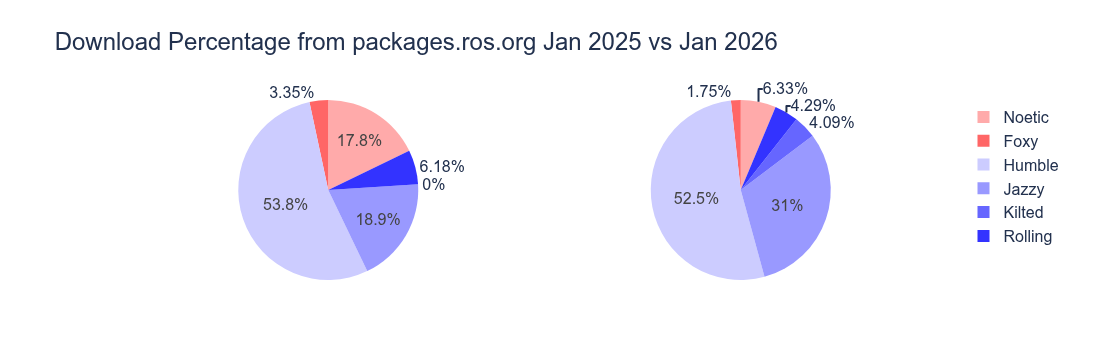

In [42]:
# Generate side by side plots of distros
temp = distro_df[distro_df[this_year]>=1].copy()
new_names = [a[0].upper()+a[1:] for a in temp["name"]]
print(new_names)
temp["name"] = pd.Series(data=new_names,copy=False,index=temp["name"].index)

new_row = pd.DataFrame(data=[{"name":"All Other Distros","2024":all_other_this,"2023":all_other_last},
                             {"name":"Python Pkgs","2024":everything_else_this,"2023":everything_else_last}])
temp = pd.concat([temp, new_row], ignore_index=True)
print(temp["name"])
print(temp)
print(temp[last_year].sum())
print(temp[this_year].sum())

title ={
    'text': "Plot Title",
    'y':0.9,
    'x':0.5,
    'xanchor': 'center',
    'yanchor': 'bottom'}

trace1 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0, 0.5]),title="",sort= False)
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="", sort=False)
layout = go.Layout(title="Download Percentage from packages.ros.org Jan 2025 vs Jan 2026")
data = [trace1,trace2]
fig = go.Figure(data=data, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=['#FFAAAA','#FF6666','#CCCCFF','#9999FF',
                                      '#6666FF','#3333FF','#fcdc3f',"#7cc14b","#EE00FF","#FF00FF"]))

fig.show()


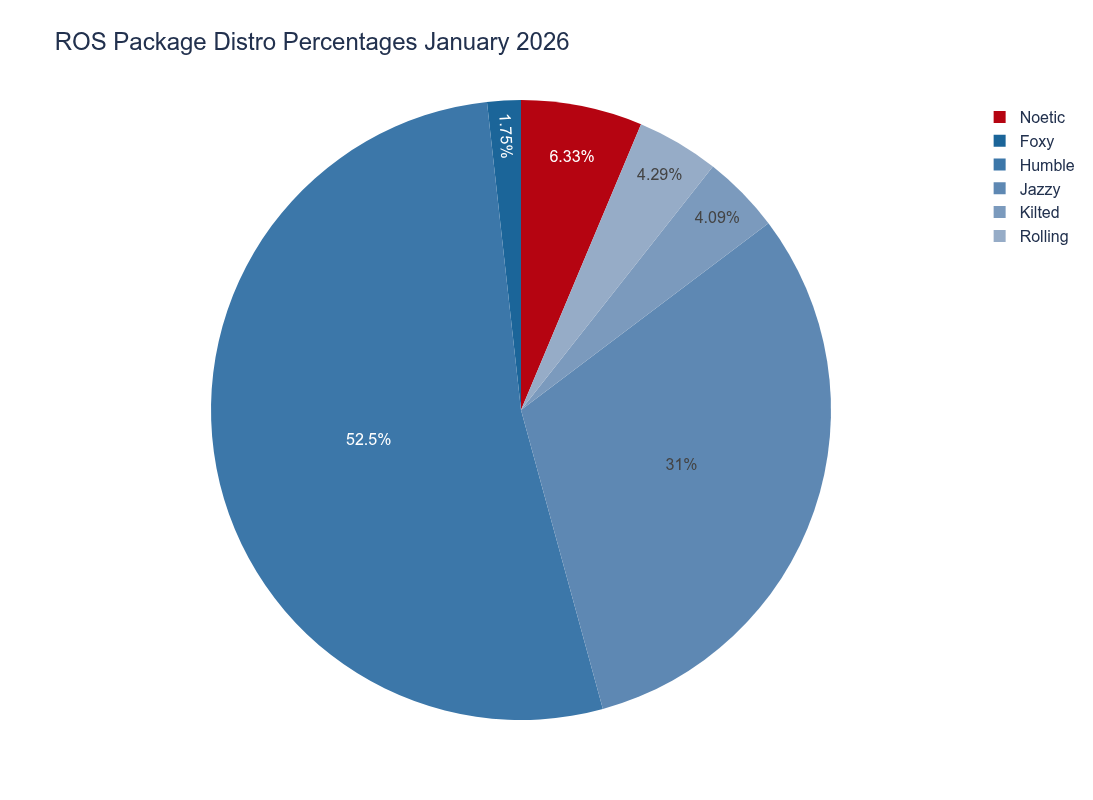

In [44]:
trace1 = go.Pie(values= temp[this_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Distro Percentages {0} {1}".format(this_month,this_year))
fig = go.Figure(data=trace1, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E",
    width = 1000,
    height = 800
)

fig.update_traces(marker=dict(colors=["#b50411","#1b6599","#3c77a9","#5e88b3","#7b9abd","#96acc7","#b0bed1"
,"#fdc6ba","#FFFF99"]))

fig.show()


In [40]:
trace2 = go.Pie(values= temp[this_year], labels = temp["name"],title="",sort= False)
layout = go.Layout(title="ROS Package Downloads by Distro {0} {1}".format(this_month,this_year))
fig = go.Figure(data=trace2, layout=layout)


fig.update_layout(
    font_family="Arial",
    font_color="#22314E",
    font_size=16,
    title_font_size = 24,
    title_font_family="Arial",
    title_font_color="#22314E"
)

fig.update_traces(marker=dict(colors=["#292f56",
"#412f4c",
"#592f43",
"#702f39",
"#882f30",
"#a02e26",
"#b82e1d",
"#cf2e13",
"#e72e0a",
"#ff2e00",]))

fig.show()


In [41]:
# Download percentages by year
temp["diff"]=temp[this_year]-temp[last_year]
temp = arch_df[arch_os_df[this_year]>0.00001]

trace1 = go.Pie(values= temp[this_year], labels = temp["name"],domain=dict(x=[0.5, 1]),title=this_year)
trace2 = go.Pie(values= temp[last_year], labels = temp["name"],domain=dict(x=[0.0,0.5]),title=last_year)

layout = go.Layout(title="ROS Packages Downloaded By Architecture - {0} {1} vs {2} {3}".format(last_month,last_year,this_year,this_month))
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()

/tmp/ipykernel_51382/3257179422.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [ ]:
fig = px.bar(distro_df, x="name", y=["2023", "2022"], title="Wide-Form Input")
fig.show()

In [ ]:
fname = "../data/march_2020.txt"
stats_mar_2020 = process_package_dump(fname,"3/2020")
fname = "../data/march_2021.txt"
stats_mar_2021 = process_package_dump(fname,"3/2021")

joined_distro = join_stats([stats_mar_2020["distro"],stats_mar_2021["distro"]])
mar_distro_df = pd.DataFrame(data=joined_distro)
mar_distro_df.to_csv("march_distro.csv")
mar_distro_df.head()
stats_mar_2021 = process_package_dump(fname,"3/2021")

In [ ]:
temp = mar_distro_df[mar_distro_df["7/2021"]>0.5]

trace1 = go.Pie(values= temp["7/2020"], labels = temp["name"],domain=dict(x=[0.5,1.0]),title="7/2020")
trace2 = go.Pie(values= temp["7/2021"], labels = temp["name"],domain=dict(x=[0, 0.5]),title="7/2021")

layout = go.Layout(title="ROS Index Download Percentage: March 2020 vs. March 2021",)
data = [trace1, trace2]
fig = go.Figure(data=data, layout=layout)
fig.show()


In [ ]:
cd ../data/


In [ ]:
stats_this